# WNTR Chlorine Modelling — Prep Work

**MSc project:** *Uncertainty-Aware Calibration of a Chlorine Decay Model*

This notebook is a starter in EPANET/WNTR chlorine simulation. This should allow you to:

1. Understand how EPANET splits chlorine decay into a **bulk** coefficient `kb` and a **wall** coefficient `kw`.
2. Have built the one function the whole project depends on:

   $$f(\theta) \;\rightarrow\; \text{simulated chlorine residuals at the monitors}, \qquad \theta = (k_b, k_w)$$

   Everything later — sensitivity analysis, calibration, uncertainty — just calls this function many times.

It runs on the bundled **Net3** practice network. When you move to the real project, swap in the 3-DMA `.inp` and your 10 monitor IDs (flagged below).

**Run order:** execute the cells top to bottom (`Shift+Enter`). Later cells depend on earlier ones.


## 0. Install dependencies (run once)

If WNTR is already in your environment, skip this cell. Otherwise run it once, then **restart the kernel**.


In [ ]:
# Run once if needed, then restart the kernel (Kernel > Restart):
# %pip install wntr matplotlib pandas numpy

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wntr

print("WNTR version:", wntr.__version__)

/opt/anaconda3/envs/cive70058/lib/python3.11/site-packages/wntr/epanet/toolkit.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


WNTR version: 1.4.0


## 1. Network and "monitors"

Net3 is a bundled EPANET example with a chlorine source — ideal for learning.

For the real project, point `PRACTICE_INP` at your 3-DMA model and replace `MONITOR_NODES`
with the node IDs nearest your 10 field-lab sensors. **Inlet monitors are excluded** — they
are *boundary conditions*, not calibration targets.


In [2]:
# --- swap these two for the real model later ---
PRACTICE_INP = os.path.join(
    os.path.dirname(wntr.__file__), "library", "networks", "Net3.inp"
)
MONITOR_NODES = ["10", "15", "20", "35", "40", "60"]   # pretend sensor locations

# The reservoirs are the chlorine entry points. In the real model the DMA-inlet
# monitors play this role: their measured trace is the boundary condition.
INLET_CHLORINE_MGL = 1.0   # mg/L imposed at the source(s)

## 2. The unit trap (read this!)

Chlorine decays first-order: $\;\dfrac{dC}{dt} = -k\,C$. EPANET splits the overall rate $k$ into:

| symbol | meaning | how you get it |
|--------|---------|----------------|
| `kb` | **bulk** decay — reactions in the water | measure via bottle tests |
| `kw` | **wall** decay — reactions at the pipe wall | **calibrate** (material/age dependent) — *this is the project's unknown* |

EPANET combines them with a mass-transfer term, so `kw`'s effect depends on pipe diameter and flow — you don't compute that yourself.

**The trap:** people quote coefficients in **per day**, but WNTR's option attributes are in SI **per second**. Forgetting this makes decay ~86,400× too weak. Always convert through the helper below, and pass **negative** values for decay.


In [3]:
SECONDS_PER_DAY = 24 * 3600

def per_day_to_per_second(value_per_day):
    """kb/kw are conventionally quoted in 1/day; WNTR wants 1/s. Decay is NEGATIVE."""
    return value_per_day / SECONDS_PER_DAY

## 3. The core function: $f(\theta) \rightarrow$ residuals

This is the object the entire project reuses. Given a parameter vector $\theta = (k_b, k_w)$ it
runs one chlorine simulation and returns the residual time series at the monitors.


In [4]:
def simulate_chlorine(kb_per_day, kw_per_day,
                      monitor_nodes=None,
                      inp_file=PRACTICE_INP,
                      inlet_mgl=INLET_CHLORINE_MGL,
                      duration_hours=48):
    """
    Run one first-order chlorine simulation; return residuals at the monitors.

    kb_per_day, kw_per_day : decay coefficients in 1/day (pass NEGATIVE for decay)
    returns : DataFrame, index = time (hours), columns = monitor nodes, units mg/L
    """
    if monitor_nodes is None:
        monitor_nodes = MONITOR_NODES
    wn = wntr.network.WaterNetworkModel(inp_file)

    # simulation clock
    wn.options.time.duration           = duration_hours * 3600
    wn.options.time.hydraulic_timestep = 3600     # 1 h hydraulics
    wn.options.time.report_timestep    = 3600     # report hourly
    wn.options.time.quality_timestep   = 300      # 5-min WQ steps (keep small!)

    # track a decaying CHEMICAL (chlorine)
    wn.options.quality.parameter     = "CHEMICAL"
    wn.options.quality.chemical_name = "Chlorine"
    wn.options.quality.inpfile_units = "mg/L"

    # first-order reaction coefficients (SI per-second; negative = decay)
    wn.options.reaction.bulk_order = 1.0
    wn.options.reaction.wall_order = 1.0
    wn.options.reaction.bulk_coeff = per_day_to_per_second(kb_per_day)
    wn.options.reaction.wall_coeff = per_day_to_per_second(kw_per_day)

    # BOUNDARY CONDITION: fix chlorine at every source/inlet.
    # Real project: replace with measured inlet-monitor series via wn.add_source(...).
    for res_name in wn.reservoir_name_list:
        wn.get_node(res_name).initial_quality = inlet_mgl

    results = wntr.sim.EpanetSimulator(wn).run_sim()

    quality = results.node["quality"]            # index = seconds, cols = node IDs
    present = [n for n in monitor_nodes if n in quality.columns]
    out = quality[present].copy()
    out.index = out.index / 3600.0               # seconds -> hours
    return out

## 4. Run one simulation and plot the residuals

A single evaluation of $f(\theta)$ with $k_b = -0.5$/day, $k_w = -0.1$/day.


In [5]:
ts = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
ts.tail(3).round(3)

name,10,15,20,35,40,60
46.0,0.863,0.266,0.100,0.685,0.164,1.000
47.0,0.845,0.081,0.832,0.650,0.164,0.998
48.0,0.828,0.079,0.831,0.713,0.161,0.998


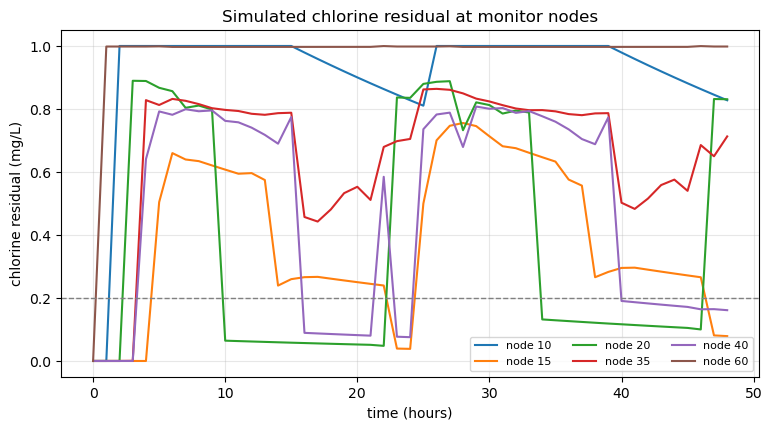

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for node in ts.columns:
    ax.plot(ts.index, ts[node], label=f"node {node}")
ax.axhline(0.2, ls="--", lw=1, color="grey")     # example residual floor
ax.set_xlabel("time (hours)")
ax.set_ylabel("chlorine residual (mg/L)")
ax.set_title("Simulated chlorine residual at monitor nodes")
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 5. Why `kw` matters: a one-parameter sensitivity sweep

This is calibration in miniature. The project's goal is to find the `kw` (and `kb`) whose curve
matches the **measured** sensor curve. Here we just watch the curves move.

We probe the monitor that decayed **most** in the baseline run — the further water has travelled,
the more cumulative wall contact, so `kw` is most identifiable there. Monitors near the inlet
barely respond to `kw`: a built-in lesson about sensor placement.


Most kw-sensitive monitor (lowest mean residual): node 20


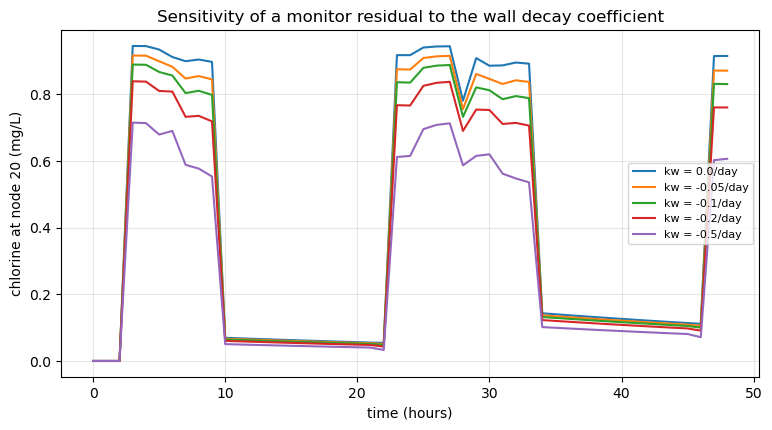

final residual vs kw: {0.0: 0.915, -0.05: 0.871, -0.1: 0.831, -0.2: 0.761, -0.5: 0.607}


In [7]:
kw_values = [0.0, -0.05, -0.1, -0.2, -0.5]
probe_node = ts.mean().idxmin()        # most-decayed monitor
print(f"Most kw-sensitive monitor (lowest mean residual): node {probe_node}")

fig2, ax2 = plt.subplots(figsize=(9, 4.5))
final_vals = {}
for kw in kw_values:
    series = simulate_chlorine(kb_per_day=-0.5, kw_per_day=kw)[probe_node]
    ax2.plot(series.index, series.values, label=f"kw = {kw}/day")
    final_vals[kw] = round(float(series.iloc[-1]), 3)
ax2.set_xlabel("time (hours)")
ax2.set_ylabel(f"chlorine at node {probe_node} (mg/L)")
ax2.set_title("Sensitivity of a monitor residual to the wall decay coefficient")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.show()
print("final residual vs kw:", final_vals)

> **Note:** if two very different `kw` values give nearly the same residual at *every* monitor,
> that `kw` is **not identifiable** from your sensors — exactly the situation the uncertainty-aware
> calibration is designed to expose.


## 6. Network map coloured by final chlorine

Spatial intuition for where the residual is lost across the network.


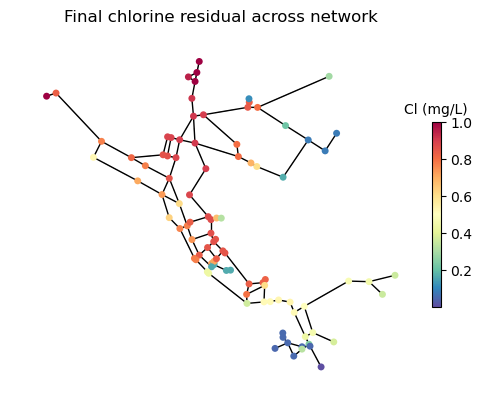

In [8]:
wn_plot = wntr.network.WaterNetworkModel(PRACTICE_INP)
wn_plot.options.time.duration     = 48 * 3600
wn_plot.options.quality.parameter = "CHEMICAL"
wn_plot.options.reaction.bulk_coeff = per_day_to_per_second(-0.5)
wn_plot.options.reaction.wall_coeff = per_day_to_per_second(-0.1)
for r in wn_plot.reservoir_name_list:
    wn_plot.get_node(r).initial_quality = INLET_CHLORINE_MGL

res_plot = wntr.sim.EpanetSimulator(wn_plot).run_sim()
final_chlorine = res_plot.node["quality"].iloc[-1]

wntr.graphics.plot_network(
    wn_plot, node_attribute=final_chlorine, node_size=25,
    node_colorbar_label="Cl (mg/L)", title="Final chlorine residual across network"
)
plt.show()

## 7. Learning exercises

Work through these *before* we proceed with the real 3-DMA model.

1. **Bulk vs wall.** Re-run with `kw = 0`. How much of Net3's residual loss is bulk vs wall? Relate to Hallam et al. (2002).
2. **Boundary scaling.** Change `INLET_CHLORINE_MGL` and confirm residuals scale ~linearly. Why does that matter for treating the inlet monitor as a boundary condition?
3. **Mass transfer.** Halve every pipe diameter (`wn.get_link(...).diameter`). Wall decay should bite harder — why? (hydraulic radius / mass transfer; EPANET manual Ch.3).
4. **Time-varying inlet.** Use `wn.add_source()` with a pattern to make the inlet vary over time, mimicking a real inlet-monitor trace. This is exactly the boundary you'll impose later.
5. **Brute-force calibrator.** Loop `simulate_chlorine()` over a `(kb, kw)` grid and compute the sum of squared errors against a synthetic "observed" run. 
